In [2]:
import ee
import geemap
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
import xgboost as xgb
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List, Tuple
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

/home/sebastian/anaconda3/envs/geo-ml/lib/python3.13/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [3]:
# Name of project in google cloud available to use with Earth Engine
EE_PROJECT = "ee-gis-scode"

try:
    ee.Authenticate()
    if EE_PROJECT:
        ee.Initialize(project=EE_PROJECT)
    else:
        ee.Initialize()
except Exception as e:
    raise RuntimeError(
        "Failed to initialize the Earth Engine client. "
    ) from e

In [4]:
# --- 1. Definir Área de Interés (AOI) ---
# Using FAO GAUL dataset to get country boundaries
countries_dataset = ee.FeatureCollection("FAO/GAUL_SIMPLIFIED_500m/2015/level2");

cuenca_ecuador = countries_dataset.filter(ee.Filter.eq('ADM1_NAME', 'Azuay')) \
                                .filter(ee.Filter.eq('ADM2_NAME', 'Cuenca'))

cuenca_aoi = cuenca_ecuador.geometry()

Map = geemap.Map()
Map.centerObject(cuenca_aoi, 10)
Map.addLayer(cuenca_aoi, {'color':'red'}, "Cuenca AOI")
display(Map)

Map(center=[-2.8614150694256804, -79.2200132598867], controls=(WidgetControl(options=['position', 'transparent…

In [26]:
try:
    hansen_dataset = ee.Image("UMD/hansen/global_forest_change_2024_v1_12").clip(cuenca_aoi)
    tree_cover_2000 = hansen_dataset.select(['treecover2000'])
    loss_year = hansen_dataset.select(['lossyear']).unmask(0) 
    gain = hansen_dataset.select(['gain']).unmask(0)
    datamask = hansen_dataset.select(['datamask']) # Útil para evitar agua/nubes procesadas
    
    print("✅ Datasets Hansen cargados")
    
except Exception as e:
    print(f"❌ Error cargando datasets: {e}")
    raise

# --- 2. DEFINICIÓN DE UMBRALES ESTRICTOS (Gap Strategy V2) ---

# Percentiles para adaptar la geografía local
stats = tree_cover_2000.reduceRegion(
    reducer=ee.Reducer.percentile([20, 80]),
    geometry=cuenca_aoi,
    scale=100,
    bestEffort=True
).getInfo()

p80 = stats.get('treecover2000_p80', 60)

# --- CAMBIO CRÍTICO 1: Umbrales Separados ---
# Para ser Bosque, debe ser denso.
FOREST_MIN_THRESHOLD = max(50, min(p80, 70)) 

# Para ser Deforestado, debió SER Bosque denso antes. 
# (Esto evita entrenar con matorrales cortados que se parecen a otras tierras)
DEFORESTATION_ORIGIN_THRESHOLD = FOREST_MIN_THRESHOLD - 10 # Ej. 40%

# Para ser Otras Tierras, debe ser muy bajo.
OTHER_LAND_MAX_THRESHOLD = 15 

print(f"🎯 ESTRATEGIA DE MUESTREO ESTRICTO (CORE PIXELS):")
print(f"   - Otras Tierras: < {OTHER_LAND_MAX_THRESHOLD}% (Solo suelo/urbano claro)")
print(f"   - Zona 'Gap' (Ignorada): {OTHER_LAND_MAX_THRESHOLD}% - {FOREST_MIN_THRESHOLD}%")
print(f"   - Bosque: >= {FOREST_MIN_THRESHOLD}%")
print(f"   - Deforestado: Pérdida donde la cobertura original era >= {DEFORESTATION_ORIGIN_THRESHOLD}%")

# --- 3. DEFINICIÓN DE MÁSCARAS (CORE LOGIC) ---

# A. MÁSCARA DE TIERRA VÁLIDA (Excluir agua mapeada por Hansen)
land_mask = datamask.eq(1) 

# B. CLASE 2: DEFORESTADO (Alta Calidad)
# Lógica: Hubo pérdida + Era vegetación densa + No es ganancia
deforested_mask = (
    loss_year.gt(0)
    .And(loss_year.lte(24))
    .And(tree_cover_2000.gte(DEFORESTATION_ORIGIN_THRESHOLD)) # ¡CRÍTICO!
    .And(land_mask)
)

# C. CLASE 1: BOSQUE ESTABLE
forest_mask = (
    tree_cover_2000.gte(FOREST_MIN_THRESHOLD)
    .And(loss_year.eq(0))
    .And(gain.eq(0)) # Sin ganancia para asegurar estabilidad
    .And(land_mask)
)

# D. CLASE 0: OTRAS TIERRAS ESTABLES
other_lands_mask = (
    tree_cover_2000.lte(OTHER_LAND_MAX_THRESHOLD)
    .And(loss_year.eq(0))
    .And(gain.eq(0))
    .And(land_mask)
)

# --- 4. LIMPIEZA DE MÁSCARAS (EROSIÓN MORFOLÓGICA) ---
# --- CAMBIO CRÍTICO 2: Eliminar bordes ---
# Usamos focal_min() para "erosionar" las máscaras. 
# Esto elimina los píxeles de borde que son mezclas espectrales.
# Nos quedamos solo con el "núcleo" (Core) de cada clase.

kernel_clean = ee.Kernel.circle(radius=1) # Radio pequeño para no perder todo

deforested_core = deforested_mask.focal_min(kernel=kernel_clean, iterations=1)
forest_core = forest_mask.focal_min(kernel=kernel_clean, iterations=1)
other_core = other_lands_mask.focal_min(kernel=kernel_clean, iterations=1)

print("✅ Máscaras erosionadas (Bordes eliminados para pureza espectral)")

# --- 5. CREACIÓN DE IMAGEN DE ETIQUETAS ---

# Base 99 (Ignorar)
label_image = ee.Image(99).byte().rename('class').clip(cuenca_aoi)

# Asignamos prioridades (Deforestado al final para asegurar que se capture)
label_image = label_image.where(other_core, 0)
label_image = label_image.where(forest_core, 1)
label_image = label_image.where(deforested_core, 2)

# Filtro final suave para eliminar ruido de un solo píxel que haya sobrevivido
label_image = label_image.focal_mode(radius=1, iterations=1)

# Enmascarar clases no válidas (Gap y Agua)
valid_classes = label_image.neq(99)
label_image = label_image.updateMask(valid_classes)

# --- 6. VALIDACIÓN Y METADATOS ---

# Calculamos histograma
try:
    pixel_counts = label_image.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=cuenca_aoi,
        scale=30, # Escala real de Hansen
        maxPixels=1e9,
        bestEffort=True
    ).get('class').getInfo()
    
    final_validation = pixel_counts if pixel_counts else {}
    
except Exception as e:
    print(f"⚠️ No se pudo validar conteos: {e}")
    final_validation = {}

# Construcción de Training Metadata
total_pixels = sum(final_validation.values()) if final_validation else 0
training_metadata = {}

print("\n📊 ESTADÍSTICAS DE PÍXELES DE ENTRENAMIENTO:")
if total_pixels > 0:
    print(f"   Total Píxeles Válidos: {total_pixels:,}")
    
    class_names = {'0': 'Otras Tierras', '1': 'Bosque', '2': 'Deforestado'}
    
    for cls, count in final_validation.items():
        pct = (count / total_pixels) * 100
        print(f"   {class_names.get(cls, cls)}: {count:,} ({pct:.2f}%)")
        
        training_metadata[f"{class_names.get(cls, cls)}_pixels"] = count
        training_metadata[f"{class_names.get(cls, cls)}_pct"] = pct

    # Alertas de balance
    count_def = final_validation.get('2', 0)
    count_forest = final_validation.get('1', 0)
    
    if count_def < 1000:
        print("\n⚠️ ADVERTENCIA: Pocos píxeles de deforestación pura encontrados.")
        print("   Sugerencia: Reducir ligeramente 'DEFORESTATION_ORIGIN_THRESHOLD'.")
    
    training_metadata['imbalance_ratio'] = final_validation.get('0', 1) / max(1, count_def)
    training_metadata['forest_threshold_used'] = FOREST_MIN_THRESHOLD
    training_metadata['processing_date'] = datetime.now().strftime('%Y-%m-%d')

else:
    print("❌ ERROR: No se encontraron píxeles válidos con estos filtros estrictos.")
    print("   Intenta relajar OTHER_LAND_MAX_THRESHOLD o revisar el AOI.")

# --- 7. VISUALIZACIÓN ---
Map = geemap.Map()
Map.centerObject(cuenca_aoi, 11)
Map.setOptions('HYBRID')

vis_params = {'min': 0, 'max': 2, 'palette': ['#a0a0a0', '#006400', '#ff0000']}
Map.addLayer(label_image, vis_params, 'Etiquetas Estrictas (Core Only)')

# Zona ignorada para debug visual
ignored = tree_cover_2000.gt(OTHER_LAND_MAX_THRESHOLD)\
          .And(tree_cover_2000.lt(FOREST_MIN_THRESHOLD))
Map.addLayer(ignored.updateMask(ignored), {'palette': ['yellow']}, 'Gap/Ignorado (Matorral)', True, 0.4)

display(Map)

✅ Datasets Hansen cargados
🎯 ESTRATEGIA DE MUESTREO ESTRICTO (CORE PIXELS):
   - Otras Tierras: < 15% (Solo suelo/urbano claro)
   - Zona 'Gap' (Ignorada): 15% - 70%
   - Bosque: >= 70%
   - Deforestado: Pérdida donde la cobertura original era >= 60%
✅ Máscaras erosionadas (Bordes eliminados para pureza espectral)

📊 ESTADÍSTICAS DE PÍXELES DE ENTRENAMIENTO:
   Total Píxeles Válidos: 2,061,003.9019607913
   Otras Tierras: 1,408,891.9058823565 (68.36%)
   Bosque: 647,775.7058823564 (31.43%)
   Deforestado: 4,336.290196078431 (0.21%)


Map(center=[-2.8614150694256804, -79.2200132598867], controls=(WidgetControl(options=['position', 'transparent…

In [6]:
# --- CONSTANTES GLOBALES (Se asume que cuenca_aoi ya está definida) ---
CLOUD_SCORE_COLLECTION = 'GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED'
SENTINEL_COLLECTION = 'COPERNICUS/S2_SR_HARMONIZED'
MAX_CLOUD_PERCENTAGE = 35
CLEAR_THRESHOLD = 0.6  # Umbral de claridad (0.6 = 60% claro)

# --- 1. FUNCIÓN DE ENMASCARAMIENTO (Cloud Score Plus) ---
def mask_s2_cs_plus(image):
    """
    Aplica una máscara de nubes y sombras usando la banda 'cs' y reescala las bandas.
    """
    # 1. Crear la máscara: cs >= 0.6
    qaBand = 'cs'
    mask = image.select(qaBand).gte(CLEAR_THRESHOLD)
    
    # 2. Reescalar y aplicar la máscara (S2_SR está en 0-10000, dividimos por 10000)
    return image.updateMask(mask).divide(10000)

# --- 2. FUNCIÓN PARA CREAR CUALQUIER COMPOSICIÓN ANUAL LIBRE DE NUBES ---
def get_annual_composite(year: int, aoi: ee.Geometry) -> ee.Image:
    """
    Crea una composición mediana (medoid) libre de nubes para un año específico
    usando el método linkCollection y el enmascaramiento Cloud Score Plus.
    """
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'
    
    # a. Colección base (S2_SR)
    s2_collection = ee.ImageCollection(SENTINEL_COLLECTION)\
        .filterDate(start_date, end_date)\
        .filterBounds(aoi)\
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', MAX_CLOUD_PERCENTAGE))

    # b. Colección de scores (CSP) y unión (linkCollection)
    cs_plus = ee.ImageCollection(CLOUD_SCORE_COLLECTION).filterDate(start_date, end_date)
    collection_with_cs = s2_collection.linkCollection(cs_plus, ['cs'])

    # c. Aplicar Máscara y Composición Mediana
    collection_sin_nubes = collection_with_cs.map(mask_s2_cs_plus)
    median_composite = collection_sin_nubes.median().clip(aoi)
    
    return median_composite
# =========================================
# 2. NUEVA INTEGRACIÓN: TENDENCIA HISTÓRICA (CORREGIDO)
# =========================================
# Función auxiliar para preparar pares [Año, NDVI] para linearFit
def create_year_ndvi(year):
    # Nota: Usamos get_annual_composite que ya tienes definida
    comp = get_annual_composite(year, cuenca_aoi)
    ndvi = comp.normalizedDifference(['B8', 'B4']).rename('ndvi')
    # Creamos una imagen constante con el valor del año (Variable X)
    year_img = ee.Image.constant(year).toFloat().rename('year')
    # Retornamos la imagen con bandas: [year, ndvi] (ORDEN IMPORTANTE PARA LINEARFIT)
    return year_img.addBands(ndvi)

# Creamos una colección con los 5 años
years_list = [2020, 2021, 2022, 2023, 2024]
trend_collection = ee.ImageCollection.fromImages([create_year_ndvi(y) for y in years_list])

# Calculamos la tendencia.
# linearFit usa la banda 0 como X (year) y la banda 1 como Y (ndvi)
ndvi_trend = trend_collection.reduce(ee.Reducer.linearFit()).select('scale').rename('NDVI_trend')
print("Tendencia histórica (2020-2024) calculada.")
# --- 3. CREACIÓN DE TODAS LAS CARACTERÍSTICAS (SPECTRALES, TEMPORALES, TOPOGRÁFICAS) ---
print("--- INICIANDO CREACIÓN DE CARACTERÍSTICAS MEJORADAS ---")

# 3.1. Composiciones Mediana para múltiples años (Mejora: más años para mejor análisis temporal)
print("--- Creando composiciones anuales (2020-2024) ---")
composite_2024 = get_annual_composite(2024, cuenca_aoi)
composite_2023 = get_annual_composite(2023, cuenca_aoi)
composite_2022 = get_annual_composite(2022, cuenca_aoi)
composite_2021 = get_annual_composite(2021, cuenca_aoi)
composite_2020 = get_annual_composite(2020, cuenca_aoi)
print("Composiciones 2020-2024 listas.")

# 3.2. CARACTERÍSTICAS TEMPORALES MEJORADAS
# Múltiples comparaciones temporales para capturar mejor los cambios
ndvi_2024 = composite_2024.normalizedDifference(['B8', 'B4']).rename('NDVI_2024')
ndvi_2023 = composite_2023.normalizedDifference(['B8', 'B4']).rename('NDVI_2023')
ndvi_2022 = composite_2022.normalizedDifference(['B8', 'B4']).rename('NDVI_2022')
ndvi_2021 = composite_2021.normalizedDifference(['B8', 'B4']).rename('NDVI_2021')
ndvi_2020 = composite_2020.normalizedDifference(['B8', 'B4']).rename('NDVI_2020')

# Diferencia entre años consecutivos (múltiples comparaciones)
ndvi_diff_2024_2023 = ndvi_2024.subtract(ndvi_2023).rename('NDVI_diff_2024_2023')
ndvi_diff_2023_2022 = ndvi_2023.subtract(ndvi_2022).rename('NDVI_diff_2023_2022')
ndvi_diff_2024_2022 = ndvi_2024.subtract(ndvi_2022).rename('NDVI_diff_2024_2022')
ndvi_diff_2024_2020 = ndvi_2024.subtract(ndvi_2020).rename('NDVI_diff_2024_2020')

# Ratio de cambio (más robusto que diferencia)
ndvi_ratio_2024_2023 = ndvi_2024.divide(ndvi_2023.add(0.001)).rename('NDVI_ratio_2024_2023')

# Media móvil de NDVI (suaviza el ruido)
ndvi_mean_3yr = ndvi_2024.add(ndvi_2023).add(ndvi_2022).divide(3).rename('NDVI_mean_3yr')

print("Características temporales mejoradas calculadas.")


# 3.3. CARACTERÍSTICAS DE ÍNDICES ESPECTRALES MEJORADAS (Basado en 2024)
# Más índices para mejor discriminación
b2 = composite_2024.select('B2').rename('Blue')
b3 = composite_2024.select('B3').rename('Green')
b4 = composite_2024.select('B4').rename('Red')
b8 = composite_2024.select('B8').rename('NIR')
b11 = composite_2024.select('B11').rename('SWIR1')  # SWIR para mejor detección
b12 = composite_2024.select('B12').rename('SWIR2')

# Índices básicos
ndvi = b8.subtract(b4).divide(b8.add(b4)).rename('NDVI')
evi = composite_2024.expression(
    '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))', {
        'NIR': b8, 'RED': b4, 'BLUE': b2
    }).rename('EVI')
savi = composite_2024.expression(
    '((NIR - RED) / (NIR + RED + 0.5)) * 1.5', {
        'NIR': b8, 'RED': b4
    }).rename('SAVI')
ndwi = b3.subtract(b8).divide(b3.add(b8)).rename('NDWI')

# NUEVOS ÍNDICES PARA MEJOR PRECISIÓN
# NBR (Normalized Burn Ratio) - excelente para detectar cambios en vegetación
nbr = composite_2024.expression(
    '(NIR - SWIR1) / (NIR + SWIR1)', {
        'NIR': b8, 'SWIR1': b11
    }).rename('NBR')

# MNDWI (Modified NDWI) - mejor detección de agua
mndwi = composite_2024.expression(
    '(GREEN - SWIR1) / (GREEN + SWIR1)', {
        'GREEN': b3, 'SWIR1': b11
    }).rename('MNDWI')

# GNDVI (Green NDVI) - más sensible a clorofila
gndvi = composite_2024.expression(
    '(NIR - GREEN) / (NIR + GREEN)', {
        'NIR': b8, 'GREEN': b3
    }).rename('GNDVI')

# NDMI (Normalized Difference Moisture Index) - contenido de humedad
ndmi = composite_2024.expression(
    '(NIR - SWIR1) / (NIR + SWIR1)', {
        'NIR': b8, 'SWIR1': b11
    }).rename('NDMI')

# BSI (Bare Soil Index) - detecta suelo desnudo
bsi = composite_2024.expression(
    '((RED + SWIR1) - (NIR + BLUE)) / ((RED + SWIR1) + (NIR + BLUE))', {
        'RED': b4, 'SWIR1': b11, 'NIR': b8, 'BLUE': b2
    }).rename('BSI')

# EVI2 (simplificado, menos dependiente del azul)
evi2 = composite_2024.expression(
    '2.5 * ((NIR - RED) / (NIR + 2.4 * RED + 1))', {
        'NIR': b8, 'RED': b4
    }).rename('EVI2')

print("Índices espectrales mejorados calculados (NDVI, EVI, SAVI, NDWI, NBR, MNDWI, GNDVI, NDMI, BSI, EVI2).")


# 3.4. CARACTERÍSTICAS AUXILIARES (TOPOGRAFÍA Y TEXTURA)

# TOPOGRAFÍA (DEM y Slope)
# Aunque parezcan irrelevantes, la topografía ayuda a contextualizar si el área
# clasificada como "Deforestado" está en un sitio donde la deforestación es común.
dem = ee.Image('USGS/SRTMGL1_003').clip(cuenca_aoi)
elevation = dem.select('elevation')
slope = ee.Terrain.slope(dem).rename('slope')
print("Características de topografía listas.")# Extraemos las dos "capas" que nos importan de la super-imagen.
#treecover2000: Una capa que muestra el porcentaje de cobertura de árboles en el año 2000. La usaremos para definir dónde había bosque originalmente.
#lossyear: Una capa donde el valor de cada píxel indica el año en que se perdió el bosque (si es que se perdió). Un valor de 23 significa que la pérdida ocurrió en 2023.

# TEXTURA (Entropy de GLCM)
# La textura (entropía) diferencia un bosque denso (uniforme) de un área
# deforestada y fragmentada (alta entropía).
# Se usa NIR (B8) y se convierte a entero para la función GLCM.
def calculate_glcm_features(band_image: ee.Image, band_name: str, window_size=4) -> ee.Image:
    """
    Calcula múltiples características de textura GLCM (Entropía, Contraste, Homogeneidad, Varianza)
    para una banda de entrada específica, renombrando las bandas de salida con un prefijo.
    """
    # Multiplicar y convertir a entero (int16) para que GLCM funcione correctamente.
    band_int = band_image.multiply(1000).toInt16()
    
    # Calcular las texturas.
    glcm = band_int.glcmTexture(size=window_size)
    
    # Extraer y renombrar las características de textura.
    entropy = glcm.select(f'{band_name}_ent').rename(f'{band_name}_entropy')
    contrast = glcm.select(f'{band_name}_contrast').rename(f'{band_name}_contrast')
    homogeneity = glcm.select(f'{band_name}_idm').rename(f'{band_name}_homogeneity')
    variance = glcm.select(f'{band_name}_var').rename(f'{band_name}_variance')
    
    # Concatenar las cuatro características en una sola imagen de bandas múltiples.
    return ee.Image.cat([entropy, contrast, homogeneity, variance])

# nir_integer = b8.multiply(1000).toInt16()
# glcm = nir_integer.glcmTexture(size=4)
# entropy = glcm.select('NIR_ent').rename('entropy') # Usamos el nuevo nombre 'NIR'
glcm_nir = calculate_glcm_features(b8, 'NIR')
glcm_red = calculate_glcm_features(b4, 'Red')
glcm_ndvi = calculate_glcm_features(ndvi, 'NDVI')

print("Característica de textura (Entropy) calculada.")

# 3.5. COMBINAR Y SELECCIONAR BANDAS FINALES

# Lista de todas las bandas a incluir en el modelo (MEJORADA con más características)
BANDS_TO_SELECT = [
    # Bandas espectrales básicas
    'Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2',
    # Índices de vegetación (básicos)
    'NDVI', 'EVI', 'SAVI', 'NDWI',
    # Índices mejorados
    'NBR', 'MNDWI', 'GNDVI', 'NDMI', 'BSI', 'EVI2',
    # Características temporales mejoradas
    'NDVI_2024', 'NDVI_2023', 'NDVI_2022',
    'NDVI_diff_2024_2023', 'NDVI_diff_2023_2022', 'NDVI_diff_2024_2022', 'NDVI_diff_2024_2020',
    'NDVI_ratio_2024_2023', 'NDVI_mean_3yr', 'NDVI_trend',
    # Topografía
    'elevation', 'slope',
    # Textura (GLCM) - múltiples bandas
    'NIR_entropy', 'NIR_contrast', 'NIR_homogeneity', 'NIR_variance',
    'Red_entropy', 'Red_contrast', 'Red_homogeneity', 'Red_variance',
    'NDVI_entropy', 'NDVI_contrast', 'NDVI_homogeneity', 'NDVI_variance'
]

# Juntamos todas las características en una sola imagen.
final_features = composite_2024.select(['B2', 'B3', 'B4', 'B8', 'B11', 'B12'])\
    .rename(['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2'])\
    .addBands([
        # Índices básicos
        ndvi, evi, savi, ndwi,
        # Índices mejorados
        nbr, mndwi, gndvi, ndmi, bsi, evi2,
        # Características temporales
        ndvi_2024, ndvi_2023, ndvi_2022,
        ndvi_diff_2024_2023, ndvi_diff_2023_2022, ndvi_diff_2024_2022, ndvi_diff_2024_2020,
        ndvi_ratio_2024_2023, ndvi_mean_3yr, ndvi_trend,
        # Topografía
        elevation, slope,
        # Textura
        glcm_nir, glcm_red, glcm_ndvi
    ])

# Aseguramos que solo tengamos las bandas deseadas y en el orden correcto
final_features = final_features.select(BANDS_TO_SELECT)


print("\n--- ¡PROCESO FINALIZADO! ---")
print("Imagen final de características creada con todas las bandas.")
print("Bandas disponibles para el modelo:", final_features.bandNames().getInfo())

Tendencia histórica (2020-2024) calculada.
--- INICIANDO CREACIÓN DE CARACTERÍSTICAS MEJORADAS ---
--- Creando composiciones anuales (2020-2024) ---
Composiciones 2020-2024 listas.
Características temporales mejoradas calculadas.
Índices espectrales mejorados calculados (NDVI, EVI, SAVI, NDWI, NBR, MNDWI, GNDVI, NDMI, BSI, EVI2).
Características de topografía listas.
Característica de textura (Entropy) calculada.

--- ¡PROCESO FINALIZADO! ---
Imagen final de características creada con todas las bandas.
Bandas disponibles para el modelo: ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'EVI', 'SAVI', 'NDWI', 'NBR', 'MNDWI', 'GNDVI', 'NDMI', 'BSI', 'EVI2', 'NDVI_2024', 'NDVI_2023', 'NDVI_2022', 'NDVI_diff_2024_2023', 'NDVI_diff_2023_2022', 'NDVI_diff_2024_2022', 'NDVI_diff_2024_2020', 'NDVI_ratio_2024_2023', 'NDVI_mean_3yr', 'NDVI_trend', 'elevation', 'slope', 'NIR_entropy', 'NIR_contrast', 'NIR_homogeneity', 'NIR_variance', 'Red_entropy', 'Red_contrast', 'Red_homogeneity', 'Red

In [30]:
import json 
from typing import List, Tuple, Dict # Asegúrate de importar Dict

def create_training_data(feature_image: ee.Image, label_image: ee.Image, aoi: ee.Geometry, 
                           num_points: int, scale: int, class_band: str) -> Tuple[ee.FeatureCollection, ee.FeatureCollection]:
    """
    Crea datos de entrenamiento BALANCEADOS mediante muestreo estratificado forzado.
    
    IMPORTANTE: El argumento 'num_points' ahora se interpreta como PUNTOS POR CLASE, 
    no como puntos totales.
    """
    print("Paso 1: Iniciando muestreo estratificado BALANCEADO...")
    
    # Unimos features y etiquetas
    training_image = feature_image.addBands(label_image)

    # --- CAMBIO CRÍTICO ---
    # Usamos classValues y classPoints para obligar a GEE a tomar la misma cantidad
    # de cada clase, ignorando el hecho de que "Otras Tierras" sea el 68% del mapa.
    
    stratified_samples = training_image.stratifiedSample(
        numPoints=0,               # Ponemos 0 porque mandan los classPoints
        classBand=class_band,
        projection='EPSG:4326',
        scale=scale,
        region=aoi,
        geometries=True,
        dropNulls=True,            # Ignorar píxeles enmascarados/vacíos
        tileScale=4,               # Vital para evitar errores de memoria con clases escasas
        classValues=[0, 1, 2],     # Las clases que definiste
        classPoints=[num_points, num_points, num_points]  # Exactamente 'num_points' para cada una
    ).randomColumn()

    # Dividimos los datos: 70% train, 30% test
    training_data = stratified_samples.filter(ee.Filter.lt('random', 0.7))
    testing_data = stratified_samples.filter(ee.Filter.gte('random', 0.7))
    
    print(f"✅ Muestreo forzado completado.")
    print(f"   Estrategia: {num_points} puntos para Clase 0, {num_points} para Clase 1, {num_points} para Clase 2.")
    print(f"   Total teórico: {num_points * 3} puntos.")
    
    return training_data, testing_data

def prepare_sklearn_data(training_gee: ee.FeatureCollection, testing_gee: ee.FeatureCollection, 
                           features: List[str], target: str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Convierte los FeatureCollections de GEE a DataFrames de Pandas y los prepara para scikit-learn.
    Elimina columnas administrativas (random, system:index, .geo) para evitar errores futuros.
    """
    print("Paso 2: Convirtiendo datos a DataFrames y preparando para el modelo...")
    
    # Convertimos los datos de GEE a Pandas DataFrames
    training_df = geemap.ee_to_df(training_gee)
    testing_df = geemap.ee_to_df(testing_gee)

    # 1. LIMPIEZA DE COLUMNAS ADMINISTRATIVAS
    # Definimos las columnas que GEE agrega y que no sirven para el modelo ni análisis
    cols_to_drop = ['random', 'system:index', '.geo']
    
    # Las borramos si existen (errors='ignore' evita fallos si alguna no está)
    training_df.drop(columns=cols_to_drop, errors='ignore', inplace=True)
    testing_df.drop(columns=cols_to_drop, errors='ignore', inplace=True)

    # 2. LIMPIEZA DE NULOS
    # Limpiamos los datos eliminando filas con valores nulos en nuestras columnas de interés.
    training_df.dropna(subset=features + [target], inplace=True)
    testing_df.dropna(subset=features + [target], inplace=True)

    # Separamos las características (X) del objetivo (y)
    # Nota: Al haber limpiado training_df arriba, esto sigue funcionando igual, 
    # pero ahora training_df y testing_df están "limpios" para guardarse en CSV.
    X_train, y_train = training_df[features], training_df[target]
    X_test, y_test = testing_df[features], testing_df[target]

    print(f"Datos listos: {len(X_train)} muestras de entrenamiento, {len(X_test)} muestras de prueba.")
    return X_train, y_train, X_test, y_test, training_df, testing_df

In [31]:
# Import the improved functions
import sys
import os
# Add the current directory to path if needed
sys.path.append(os.getcwd())
from training_utils import train_and_evaluate_model_optimized, save_optimized_artifacts


BANDS = BANDS_TO_SELECT 
CLASS_BAND = 'class'
POINTS_PER_CLASS = 15000
SCALE = 10
MODEL_FILENAME = 'deforestation_model_optimized.pkl'

# 1. Crear datos de entrenamiento y prueba

training_gee, testing_gee = create_training_data(
    feature_image=final_features,
    label_image=label_image,
    aoi=cuenca_aoi,
    num_points=POINTS_PER_CLASS,
    scale=SCALE,
    class_band=CLASS_BAND
)

# 2. Preparar los datos para scikit-learn
# Usamos la lista de bandas correcta que coincide con la imagen
X_train, y_train, X_test, y_test, train_df, test_df = prepare_sklearn_data(
    training_gee=training_gee,
    testing_gee=testing_gee,
    features=BANDS,
    target=CLASS_BAND
)

# Run the training
best_model, search_results, feature_importance, scaler, selector = train_and_evaluate_model_optimized(
    X_train, y_train, X_test, y_test, 
    training_metadata=training_metadata
)
# Save artifacts
save_optimized_artifacts(
    best_model, train_df, test_df,
    'deforestation_model_optimized.pkl',
    training_metadata,
    feature_importance,
    search_results,
    scaler,
    selector
)

Paso 1: Iniciando muestreo estratificado BALANCEADO...
✅ Muestreo forzado completado.
   Estrategia: 15000 puntos para Clase 0, 15000 para Clase 1, 15000 para Clase 2.
   Total teórico: 45000 puntos.
Paso 2: Convirtiendo datos a DataFrames y preparando para el modelo...
Datos listos: 31535 muestras de entrenamiento, 13465 muestras de prueba.

Paso 3: Entrenando modelo RandomForest con optimizaciones avanzadas...

🔍 Probando técnica: adaptive_smote
   Ejecutando búsqueda para adaptive_smote...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
   Score obtenido: 0.8166

🔍 Probando técnica: smote_tomek_balanced
   Ejecutando búsqueda para smote_tomek_balanced...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
   Score obtenido: 0.8139

✅ MEJOR MODELO ENCONTRADO:
   Técnica: adaptive_smote

ACCURACY FINAL: 0.8224 (82.24%)

Reporte de Clasificación:
                   precision    recall  f1-score   support

Otras Tierras (0)     0.9225    0.8219    0.8693      450

                        XGBOOST

In [1]:
from sklearn.model_selection import GridSearchCV
def create_training_data(feature_image: ee.Image, label_image: ee.Image, aoi: ee.Geometry, 
                           num_points: int, scale: int, class_band: str) -> Tuple[ee.FeatureCollection, ee.FeatureCollection]:
    """
    Crea datos de entrenamiento y prueba mediante muestreo estratificado en GEE.
    MEJORADO: Más validación de datos y mejor filtrado.
    """
    print("Paso 1: Iniciando muestreo estratificado mejorado...")
    
    # Unimos features y etiquetas en una sola imagen para el muestreo.
    training_image = feature_image.addBands(label_image)

    # MEJORA: Filtrado más robusto de datos inválidos
    # Validar múltiples bandas críticas
    valid_mask = (
        feature_image.select(['NDVI']).gt(-1).And(feature_image.select(['NDVI']).lt(1))
        .And(feature_image.select(['Blue']).gt(0).And(feature_image.select(['Blue']).lt(1)))
        .And(feature_image.select(['NIR']).gt(0).And(feature_image.select(['NIR']).lt(1)))
    )
    
    training_image = training_image.updateMask(valid_mask)

    # MEJORA: Aumentar muestras para mejor representación
    # Realizamos el muestreo, asegurando un número igual de puntos por clase.
    stratified_samples = training_image.stratifiedSample(
        numPoints=num_points,
        classBand=class_band,
        projection='EPSG:4326',
        scale=scale,
        region=aoi,
        geometries=True,  # Incluir la geometría de los puntos
        seed=42  # Semilla para reproducibilidad
    ).randomColumn()  # Añade una columna aleatoria para la división train/test

    # Dividimos los datos: 80% para entrenamiento, 20% para prueba (mejor para más datos)
    training_data = stratified_samples.filter(ee.Filter.lt('random', 0.8))
    testing_data = stratified_samples.filter(ee.Filter.gte('random', 0.8))
    
    print(f"Muestreo completado. Se dividirán los puntos para entrenamiento y prueba.")
    return training_data, testing_data

def prepare_sklearn_data(training_gee: ee.FeatureCollection, testing_gee: ee.FeatureCollection, 
                           features: List[str], target: str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, List[str]]:
    """
    Convierte los FeatureCollections de GEE a DataFrames de Pandas y los prepara para scikit-learn.
    MEJORADO: Limpieza de datos, eliminación de outliers, y feature selection.
    """
    print("Paso 2: Convirtiendo datos a DataFrames y preparando para el modelo...")
    
    # Convertimos los datos de GEE a Pandas DataFrames
    training_df = geemap.ee_to_df(training_gee)
    testing_df = geemap.ee_to_df(testing_gee)

    # Limpiamos los datos eliminando filas con valores nulos
    training_df.dropna(subset=features + [target], inplace=True)
    testing_df.dropna(subset=features + [target], inplace=True)

    # MEJORA: Eliminación de outliers usando método más conservador
    print("   Eliminando outliers (método conservador)...")
    initial_train_size = len(training_df)
    initial_test_size = len(testing_df)
    
    # Crear máscaras para train y test
    train_mask = pd.Series([True] * len(training_df), index=training_df.index)
    test_mask = pd.Series([True] * len(testing_df), index=testing_df.index)
    
    for feature in features:
        # Calcular límites basados en training data
        Q1 = training_df[feature].quantile(0.005)  # Percentiles muy amplios
        Q3 = training_df[feature].quantile(0.995)
        IQR = Q3 - Q1
        lower_bound = Q1 - 4 * IQR  # Muy permisivo
        upper_bound = Q3 + 4 * IQR
        
        # Aplicar a ambos datasets
        train_mask = train_mask & (training_df[feature] >= lower_bound) & (training_df[feature] <= upper_bound)
        test_mask = test_mask & (testing_df[feature] >= lower_bound) & (testing_df[feature] <= upper_bound)
    
    # Aplicar filtros
    training_df = training_df[train_mask]
    testing_df = testing_df[test_mask]
    
    removed_train = initial_train_size - len(training_df)
    removed_test = initial_test_size - len(testing_df)
    print(f"   Eliminados {removed_train} outliers de entrenamiento ({removed_train/initial_train_size*100:.2f}%)")
    print(f"   Eliminados {removed_test} outliers de prueba ({removed_test/initial_test_size*100:.2f}%)")

    # Separamos las características (X) del objetivo (y)
    X_train, y_train = training_df[features], training_df[target]
    X_test, y_test = testing_df[features], testing_df[target]

    # MEJORA: Feature Selection usando SelectKBest
    print("   Aplicando feature selection...")
    # Seleccionar las mejores características basadas en f_classif
    k_best = min(50, len(features))  # Seleccionar hasta 50 mejores features
    selector = SelectKBest(score_func=f_classif, k=k_best)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)
    
    # Obtener nombres de características seleccionadas
    selected_features = [features[i] for i in selector.get_support(indices=True)]
    print(f"   {len(selected_features)} características seleccionadas de {len(features)} originales.")
    
    # Convertir de vuelta a DataFrame
    X_train = pd.DataFrame(X_train_selected, columns=selected_features, index=X_train.index)
    X_test = pd.DataFrame(X_test_selected, columns=selected_features, index=X_test.index)

    print(f"Datos listos: {len(X_train)} muestras de entrenamiento, {len(X_test)} muestras de prueba.")
    print(f"Características seleccionadas: {len(selected_features)}")
    return X_train, y_train, X_test, y_test, training_df, testing_df, selected_features

def train_and_evaluate_model(X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series):
    """
    Entrena un modelo XGBoost (mejor que RandomForest) y evalúa su rendimiento.
    MEJORADO: Usa XGBoost con mejor tuning de hiperparámetros.
    """
    print("\nPaso 3: Iniciando la optimización de hiperparámetros con XGBoost...")

    # MEJORA: Usar XGBoost en lugar de RandomForest (generalmente mejor rendimiento)
    # 1. Define la rejilla de parámetros optimizada para XGBoost
    param_grid = {
        'n_estimators': [200, 300, 400],      # Más árboles para mejor rendimiento
        'max_depth': [6, 8, 10],              # Profundidad moderada
        'learning_rate': [0.01, 0.05, 0.1],   # Learning rate más bajo
        'subsample': [0.8, 0.9, 1.0],         # Submuestreo para evitar overfitting
        'colsample_bytree': [0.8, 0.9, 1.0], # Submuestreo de características
        'min_child_weight': [1, 3, 5]         # Control de complejidad
    }

    # 2. Inicializa el modelo base XGBoost
    xgb_model = xgb.XGBClassifier(
        random_state=42,
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',  # Más rápido
        n_jobs=-1,
        use_label_encoder=False
    )

    # 3. Configura y ejecuta GridSearchCV con validación cruzada estratificada
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid_search = GridSearchCV(
        estimator=xgb_model, 
        param_grid=param_grid, 
        cv=skf, 
        n_jobs=-1, 
        verbose=2,
        scoring='accuracy',  # Optimizar por accuracy
        refit=True
    )
    
    print("   Entrenando modelo (esto puede tardar varios minutos)...")
    grid_search.fit(X_train, y_train)

    # 4. Obtén el mejor modelo y sus parámetros
    print("\n¡Optimización completada!")
    print(f"Los mejores parámetros encontrados son: {grid_search.best_params_}")
    print(f"Mejor score de validación cruzada: {grid_search.best_score_:.4f}")
    best_model = grid_search.best_estimator_

    # 5. Evalúa el rendimiento del MEJOR modelo
    print("\nPaso 4: Evaluando el rendimiento del modelo optimizado...")
    y_pred = best_model.predict(X_test)
    
    # Calcular accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n{'='*60}")
    print(f"ACCURACY FINAL: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"{'='*60}")
    
    # Generar y mostrar el reporte de clasificación
    class_labels = ['Otras Tierras (0)', 'Bosque (1)', 'Deforestado (2)']
    report = classification_report(y_test, y_pred, target_names=class_labels, digits=4)
    print("\nReporte de Clasificación:")
    print(report)

    # Generar y guardar la matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Matriz de Confusión - Accuracy: {accuracy:.4f}')
    plt.ylabel('Clase Real')
    plt.xlabel('Clase Predicha')
    plt.tight_layout()
    plt.savefig('confusion_matrix_optimized.png', dpi=300)
    print("\nMatriz de confusión guardada como 'confusion_matrix_optimized.png'")
    
    # MEJORA: Mostrar importancia de características
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 10 características más importantes:")
    print(feature_importance.head(10).to_string(index=False))
    
    return best_model

def save_artifacts(classifier, training_df: pd.DataFrame, testing_df: pd.DataFrame, model_filename: str, selected_features: List[str]):
    """
    Guarda el modelo entrenado y los DataFrames de muestra.
    MEJORADO: También guarda las características seleccionadas.
    """
    print("\nPaso 5: Guardando el modelo y los datos de muestra...")
    joblib.dump(classifier, model_filename)
    training_df.to_csv('training_samples.csv', index=False)
    testing_df.to_csv('testing_samples.csv', index=False)
    
    # Guardar lista de características seleccionadas
    features_df = pd.DataFrame({'feature': selected_features})
    features_df.to_csv('selected_features.csv', index=False)
    
    print(f"¡PROCESO COMPLETADO! Modelo guardado como '{model_filename}'")
    print(f"Características seleccionadas guardadas en 'selected_features.csv'")

NameError: name 'ee' is not defined

INICIANDO ENTRENAMIENTO DEL MODELO MEJORADO
Características totales: 40
Muestras por clase: 15000
Escala: 10m
Paso 1: Iniciando muestreo estratificado mejorado...
Muestreo completado. Se dividirán los puntos para entrenamiento y prueba.
Paso 2: Convirtiendo datos a DataFrames y preparando para el modelo...
   Eliminando outliers (método conservador)...
   Eliminados 37 outliers de entrenamiento (0.10%)
   Eliminados 8 outliers de prueba (0.09%)
   Aplicando feature selection...
   40 características seleccionadas de 40 originales.
Datos listos: 35955 muestras de entrenamiento, 9000 muestras de prueba.
Características seleccionadas: 40

Paso 3: Iniciando la optimización de hiperparámetros con XGBoost...
   Entrenando modelo (esto puede tardar varios minutos)...
Fitting 5 folds for each of 729 candidates, totalling 3645 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, min_child_weight=1, n_estimators=200, subsample=0.9; total time=  26.3s
[CV] END colsample_bytree=0.8

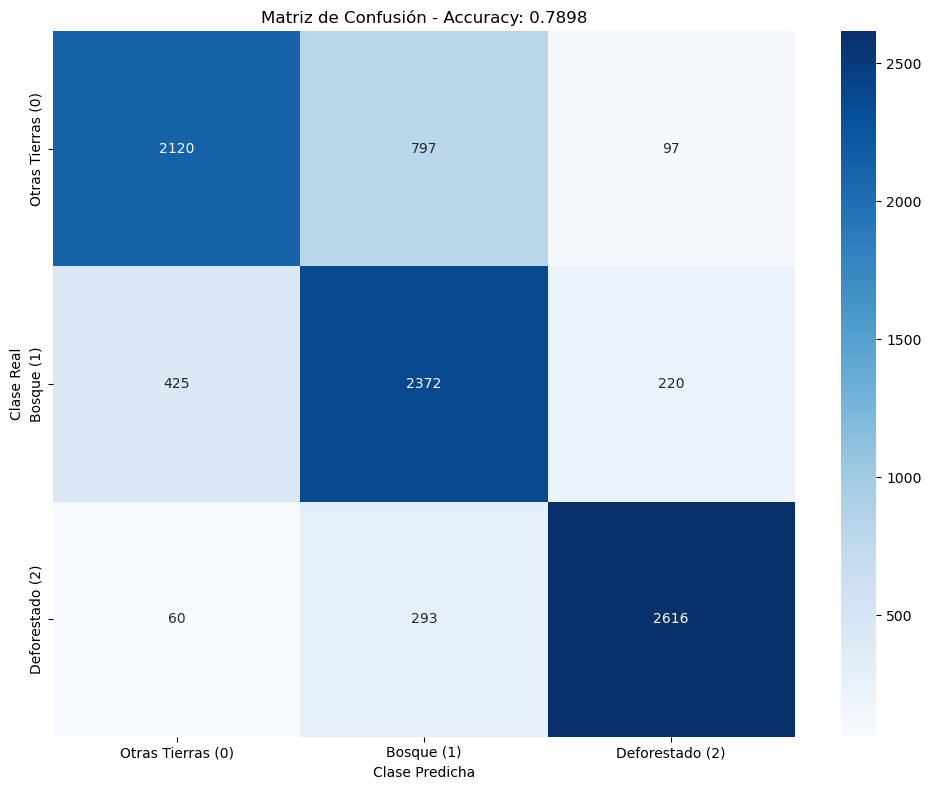

In [9]:
BANDS = BANDS_TO_SELECT
CLASS_BAND = 'class'
POINTS_PER_CLASS = 15000   # MEJORA: Aumentar muestras por clase para mejor representación
SCALE = 10                 # usar 10 m para Sentinel-2
MODEL_FILENAME = 'deforestation_model_v4.pkl'

print("="*60)
print("INICIANDO ENTRENAMIENTO DEL MODELO MEJORADO")
print("="*60)
print(f"Características totales: {len(BANDS)}")
print(f"Muestras por clase: {POINTS_PER_CLASS}")
print(f"Escala: {SCALE}m")
print("="*60)

# 1. Crear datos de entrenamiento y prueba
class_labels_image = label_image.select('constant').rename(CLASS_BAND)

# Pasamos la imagen `final_features` con todas las características mejoradas
training_gee, testing_gee = create_training_data(
    feature_image=final_features,
    label_image=class_labels_image,
    aoi=cuenca_aoi,
    num_points=POINTS_PER_CLASS,
    scale=SCALE,
    class_band=CLASS_BAND
)

# 2. Preparar los datos para scikit-learn (con feature selection y limpieza)
X_train, y_train, X_test, y_test, train_df, test_df, selected_features = prepare_sklearn_data(
    training_gee=training_gee,
    testing_gee=testing_gee,
    features=BANDS,
    target=CLASS_BAND
)

# 3. Entrenar y evaluar el modelo (XGBoost mejorado)
trained_model = train_and_evaluate_model(X_train, y_train, X_test, y_test)

# 4. Guardar los artefactos finales
save_artifacts(trained_model, train_df, test_df, MODEL_FILENAME, selected_features)

print("\n" + "="*60)
print("ENTRENAMIENTO COMPLETADO")
print("="*60)